In [ ]:
import torch
torch.cuda.is_available()

True

In [ ]:
!pip install -q torch datasets transformers tqdm matplotlib scikit-learn

In [ ]:
# Cell 1：导入包 + 配置
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer
from tqdm import tqdm
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

MAX_LEN = 256
BATCH_SIZE = 32
EPOCHS = 3

Device: cuda


In [ ]:
# Cell 2：加载数据
dataset = load_dataset("imdb")

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

vocab_size = tokenizer.vocab_size
pad_id = tokenizer.pad_token_id

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [ ]:
import os, random, numpy as np, torch
from torch.utils.data import DataLoader

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# 固定同一批样本索引
N_TRAIN = 20000
N_TEST = 5000

train_perm = np.random.RandomState(42).permutation(len(dataset["train"]))[:N_TRAIN]
test_perm  = np.random.RandomState(123).permutation(len(dataset["test"]))[:N_TEST]

train_ds = dataset["train"].select(train_perm.tolist())
test_ds  = dataset["test"].select(test_perm.tolist())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

# 打印一个“指纹”，确保每次跑的是同一批数据
print("train_idx_fingerprint:", int(train_perm[:10].sum()), int(train_perm[-10:].sum()))
print("test_idx_fingerprint :", int(test_perm[:10].sum()), int(test_perm[-10:].sum()))
print("train size:", len(train_ds), "test size:", len(test_ds))

train_idx_fingerprint: 107364 109996
test_idx_fingerprint : 149168 132605
train size: 20000 test size: 5000


In [ ]:
# Cell 3：定义模型（带 Attention）
class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.w = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, h, mask):
        scores = self.v(torch.tanh(self.w(h))).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e9)
        attn = F.softmax(scores, dim=-1)
        context = torch.bmm(attn.unsqueeze(1), h).squeeze(1)
        return context, attn


class BiLSTMAttnClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128, num_classes=2, drop=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.emb_drop = nn.Dropout(drop)

        self.lstm = nn.LSTM(
            emb_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True,
            num_layers=2,
            dropout=drop,   # 只有 num_layers>1 才生效
        )

        self.out_drop = nn.Dropout(drop)
        self.attn = AdditiveAttention(hidden_dim * 2)
        self.attn_drop = nn.Dropout(drop)

        self.fc_drop = nn.Dropout(drop)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask, return_attn=False):
      x = self.emb_drop(self.embedding(input_ids))
      h, _ = self.lstm(x)
      h = self.out_drop(h)

      context, attn = self.attn(h, attention_mask)

      attn_used = self.attn_drop(attn)
      attn_used = attn_used * attention_mask
      attn_used = attn_used / (attn_used.sum(dim=-1, keepdim=True).clamp(min=1e-6))
      context = torch.bmm(attn_used.unsqueeze(1), h).squeeze(1)

      logits = self.fc(self.fc_drop(context))

      if return_attn:
          return logits, attn_used
      return logits

## Baseline 模型代码

In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128, num_classes=2, drop=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.emb_drop = nn.Dropout(drop)
        self.lstm = nn.LSTM(
            emb_dim, hidden_dim,
            batch_first=True, bidirectional=True,
            num_layers=1  # baseline用1层更稳
        )
        self.out_drop = nn.Dropout(drop)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        x = self.emb_drop(self.embedding(input_ids))
        h, _ = self.lstm(x)
        h = self.out_drop(h)

        mask = attention_mask.unsqueeze(-1).float()
        pooled = (h * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
        return self.fc(pooled)

In [ ]:
# Cell 4：训练函数
def train_one_epoch(model, loader, optimizer, clip=1.0):
    model.train()
    total_loss = 0
    ce = nn.CrossEntropyLoss()
    for batch in tqdm(loader, leave=False):
        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = model(input_ids, mask)
        loss = ce(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        logits = model(input_ids, mask)
        preds = logits.argmax(dim=-1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total

In [ ]:
# Cell5：训练
def run_train(model, name, lr=1e-3, wd=0.0, epochs=3):
    seed_everything(42)  # 每次训练前重置seed，减少初始化差异
    model = model.to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_acc, best_epoch = 0.0, 0
    for ep in range(epochs):
        loss = train_one_epoch(model, train_loader, optim)
        acc = evaluate(model, test_loader)
        print(f"[{name}] epoch={ep+1} loss={loss:.4f} acc={acc:.4f}")
        if acc > best_acc:
            best_acc, best_epoch = acc, ep+1
    print(f"[{name}] best_acc={best_acc:.4f} @epoch {best_epoch}\n")
    return best_acc

In [ ]:
baseline_acc = run_train(BiLSTMClassifier(vocab_size), "Baseline", lr=1e-3, wd=0.0, epochs=3)
attn_acc     = run_train(BiLSTMAttnClassifier(vocab_size), "Attention", lr=1e-3, wd=0.01, epochs=3)
print("FINAL:", baseline_acc, attn_acc)

[Baseline] epoch=1 loss=0.4886 acc=0.8392


[Baseline] epoch=2 loss=0.3145 acc=0.8622


[Baseline] epoch=3 loss=0.2362 acc=0.8542
[Baseline] best_acc=0.8622 @epoch 2



[Attention] epoch=1 loss=0.5088 acc=0.8200


[Attention] epoch=2 loss=0.3362 acc=0.8560


[Attention] epoch=3 loss=0.2671 acc=0.8504
[Attention] best_acc=0.8560 @epoch 2

FINAL: 0.8622 0.856


In [ ]:
import numpy as np
import torch

SEEDS = [40, 41, 42]     # 你也可以换成更多，比如 [1,2,3,4,5]
EPOCHS = 3

def run_once(model_ctor, seed, name, lr=1e-3, wd=0.0):
    seed_everything(seed)
    model = model_ctor().to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    best_acc, best_epoch = 0.0, 0
    for ep in range(EPOCHS):
        loss = train_one_epoch(model, train_loader, optim)
        acc = evaluate(model, test_loader)
        if acc > best_acc:
            best_acc, best_epoch = acc, ep+1
    return best_acc, best_epoch

def summarize(arr):
    arr = np.array(arr, dtype=float)
    return float(arr.mean()), float(arr.std(ddof=1)) if len(arr) > 1 else 0.0

baseline_best = []
attn_best = []

for s in SEEDS:
    b_acc, b_ep = run_once(lambda: BiLSTMClassifier(vocab_size), s, "Baseline", lr=1e-3, wd=0.0)
    a_acc, a_ep = run_once(lambda: BiLSTMAttnClassifier(vocab_size), s, "Attention", lr=1e-3, wd=0.01)

    baseline_best.append(b_acc)
    attn_best.append(a_acc)

    print(f"seed={s} | Baseline best={b_acc:.4f} (ep{b_ep}) | Attention best={a_acc:.4f} (ep{a_ep})")

b_mean, b_std = summarize(baseline_best)
a_mean, a_std = summarize(attn_best)

print("\n===== Summary (best acc over epochs) =====")
print(f"Baseline : mean={b_mean:.4f}, std={b_std:.4f}, runs={baseline_best}")
print(f"Attention: mean={a_mean:.4f}, std={a_std:.4f}, runs={attn_best}")
print("Delta (Attn - Base):", f"{(a_mean - b_mean):+.4f}")

seed=40 | Baseline best=0.8506 (ep3) | Attention best=0.8552 (ep3)


seed=41 | Baseline best=0.8570 (ep2) | Attention best=0.8556 (ep3)


seed=42 | Baseline best=0.8608 (ep3) | Attention best=0.8678 (ep3)

===== Summary (best acc over epochs) =====
Baseline : mean=0.8561, std=0.0052, runs=[0.8506, 0.857, 0.8608]
Attention: mean=0.8595, std=0.0072, runs=[0.8552, 0.8556, 0.8678]
Delta (Attn - Base): +0.0034


In [ ]:
# Cell 6：写可视化函数
import numpy as np
import matplotlib.pyplot as plt
import torch

@torch.no_grad()
def explain_sentence_clean(model, sentence, topk=12):
    model.eval()

    enc = tokenizer(
        sentence,
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
        return_tensors="pt",
    )
    input_ids = enc["input_ids"].to(device)
    mask = enc["attention_mask"].to(device)

    logits, attn = model(input_ids, mask, return_attn=True)   # attn: [1, T]
    prob = torch.softmax(logits, dim=-1)[0].detach().cpu().numpy()
    pred = int(prob.argmax())

    ids = enc["input_ids"][0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(ids)

    valid_len = int(enc["attention_mask"][0].sum().item())
    tokens = tokens[:valid_len]
    weights = attn[0][:valid_len].detach().cpu().numpy()

    # 过滤特殊token
    special = set(tokenizer.all_special_tokens)  # ['[PAD]','[CLS]','[SEP]',...]
    filt_tokens, filt_weights = [], []
    for t, w in zip(tokens, weights):
        if t in special:
            continue
        filt_tokens.append(t)
        filt_weights.append(float(w))

    # 合并 subword：把 "##" 拼回去，权重求和
    merged_tokens, merged_weights = [], []
    for tok, w in zip(filt_tokens, filt_weights):
        if tok.startswith("##") and merged_tokens:
            merged_tokens[-1] = merged_tokens[-1] + tok[2:]
            merged_weights[-1] += w
        else:
            merged_tokens.append(tok)
            merged_weights.append(w)

    # 归一化（防止过滤特殊token后和不为1）
    s = sum(merged_weights)
    if s > 0:
        merged_weights = [w / s for w in merged_weights]

    # topk
    idx = np.argsort(merged_weights)[::-1][:topk]
    top_items = [(merged_tokens[i], merged_weights[i]) for i in idx]

    # 画图
    words = [x[0] for x in top_items][::-1]
    vals  = [x[1] for x in top_items][::-1]

    plt.figure(figsize=(8, 4))
    plt.barh(words, vals)
    plt.title(f"Pred={pred}  Prob={prob[pred]:.4f}  (0=neg,1=pos)")
    plt.xlabel("Attention weight")
    plt.tight_layout()
    plt.show()

    return pred, prob, top_items

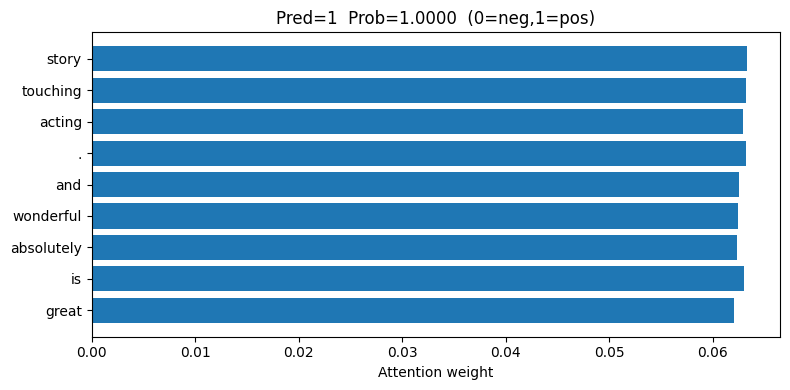

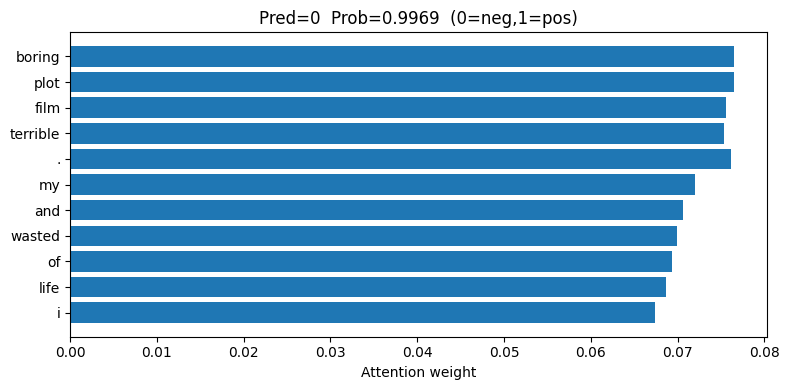

(0,
 array([0.9969304 , 0.00306956], dtype=float32),
 [('boring', 0.07651159660137445),
  ('plot', 0.07649607966936925),
  ('.', 0.07611876331283693),
  ('film', 0.07554609100639562),
  ('terrible', 0.07540167404771651),
  ('.', 0.0724293347240291),
  ('my', 0.07196844591673003),
  ('and', 0.07068651979705187),
  ('wasted', 0.0699689515086722),
  ('of', 0.06941349837760383),
  ('life', 0.0686891168387599),
  ('i', 0.06738983895691385)])

In [ ]:
# Cell 7：试两句话
s1 = "This movie is absolutely wonderful. The acting is great and the story is touching."
s2 = "Terrible film. Boring plot and I wasted two hours of my life."

attn_model = BiLSTMAttnClassifier(vocab_size).to(device)

explain_sentence_clean(attn_model, s1)
explain_sentence_clean(attn_model, s2)

In [ ]:
from IPython.display import HTML, display
import numpy as np
import re
import torch

@torch.no_grad()
def highlight_html(model, sentence, max_len=256, topk=None, drop_punct=True, drop_stopwords=False):
    model.eval()

    enc = tokenizer(
        sentence,
        truncation=True,
        padding="max_length",
        max_length=max_len,
        return_tensors="pt",
    )
    input_ids = enc["input_ids"].to(device)
    mask = enc["attention_mask"].to(device)

    logits, attn = model(input_ids, mask, return_attn=True)  # attn: [1,T] 已对齐“实际使用的权重”
    prob = torch.softmax(logits, dim=-1)[0].detach().cpu().numpy()
    pred = int(prob.argmax())

    ids = enc["input_ids"][0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(ids)
    valid_len = int(enc["attention_mask"][0].sum().item())

    tokens = tokens[:valid_len]
    weights = attn[0][:valid_len].detach().cpu().numpy()

    # 过滤特殊 token
    special = set(tokenizer.all_special_tokens)
    toks, ws = [], []
    for t, w in zip(tokens, weights):
        if t in special:
            continue
        toks.append(t)
        ws.append(float(w))

    # 合并 ## 子词（权重求和）
    merged_toks, merged_ws = [], []
    for t, w in zip(toks, ws):
        if t.startswith("##") and merged_toks:
            merged_toks[-1] = merged_toks[-1] + t[2:]
            merged_ws[-1] += w
        else:
            merged_toks.append(t)
            merged_ws.append(w)

    merged_ws = np.array(merged_ws, dtype=float)
    if merged_ws.sum() > 0:
        merged_ws = merged_ws / merged_ws.sum()

    # 可选：只保留 topk，让高亮更“尖锐”
    if topk is not None and 0 < topk < len(merged_ws):
        keep = np.argsort(merged_ws)[::-1][:topk]
        w2 = np.zeros_like(merged_ws)
        w2[keep] = merged_ws[keep]
        # 颜色强度用 max 归一化（视觉更明显）
        merged_ws = w2 / (w2.max() + 1e-12)

    # 可选：去标点 / 去停用词（让展示更像论文）
    stopwords = set(["the","a","an","is","are","am","and","or","of","to","in","on","for","it","this","that","i","my","was"])
    def is_punct(tok):
        return re.fullmatch(r"[^\w]+", tok) is not None  # 全是非字母数字下划线

    html_parts = []
    for t, w in zip(merged_toks, merged_ws):
        if drop_punct and is_punct(t):
            # 标点直接正常显示（不高亮）
            html_parts.append(f"<span style='margin-right:2px'>{t}</span>")
            continue
        if drop_stopwords and t.lower() in stopwords:
            html_parts.append(f"<span style='margin-right:2px'>{t}</span>")
            continue

        # 背景透明度：w 越大越深（0~1）
        alpha = float(np.clip(w, 0, 1)) * 0.85
        html_parts.append(
            f"<span style='background: rgba(30, 144, 255, {alpha});"
            f" padding:2px 4px; margin-right:2px; border-radius:4px;'>"
            f"{t}</span>"
        )

    title = f"<div style='font-size:16px; margin-bottom:6px;'><b>Pred={pred}</b> &nbsp; Prob={prob[pred]:.4f} &nbsp; (0=neg,1=pos)</div>"
    body = "<div style='font-size:18px; line-height:2.0;'>" + " ".join(html_parts) + "</div>"
    display(HTML(title + body))

    return pred, prob

In [ ]:
s1 = "This movie is absolutely wonderful. The acting is great and the story is touching."
s2 = "Terrible film. Boring plot and I wasted two hours of my life."

highlight_html(attn_model, s1, max_len=MAX_LEN, topk=6, drop_punct=True, drop_stopwords=False)
highlight_html(attn_model, s2, max_len=MAX_LEN, topk=6, drop_punct=True, drop_stopwords=False)

(0, array([0.9969304 , 0.00306956], dtype=float32))